## Simulating observational effects for synthetic Integral Field Spectroscopy (IFS) data
Beyond broadband imaging, GalSyn allows us to simulate realistic Integral Field Unit (IFU) observations. This process transforms idealized spectral cubes into mock IFU observations by accounting for wavelength-dependent sensitivity, instrumental resolution, and spatial blurring.

In this example, we will simulate mock JWST NIRSpec IFU high-resolution data using the G140H/F070LP configuration. There are couple of things we need to prepare for this. First, we will use PSF model generated using the [STPSF package](https://stpsf.readthedocs.io/en/latest/jwst_ifu_datacubes.html#Simulating-IFU-mode-and-Datacubes) and transform it into a standardized format required by GalSyn. Then, we will simulate wavelength-dependent sensitivity limits of the NIRSpec IFU G140H/F070LP instrument configuration using the [Pandeia ETC engine](https://jwst-docs.stsci.edu/jwst-exposure-time-calculator-overview/jwst-etc-pandeia-engine-tutorial#gsc.tab=0). Once we have done all of these, we will run the mock IFU data generation. 

### Preparing the standardized PSF data cube
The ``observe`` module requires a PSF cube where the wavelength axis matches your desired output grid. Since STPSF outputs multiple extensions, we first extract and standardize the ``DET_DIST`` data.

In [5]:
import numpy as np
from astropy.io import fits

# The PSF FITS file from STPSF package has multiple extensions. 
# We use the DET_DIST extension and store it in a single-extension file.
hdu = fits.open('psf_cube_G140H_F100LP.fits')
psf_cube_data = hdu['DET_DIST'].data

# Extract wavelength information for each slice in the PSF cube
cube_psf_wave_um = np.zeros(psf_cube_data.shape[0])
for i in range(psf_cube_data.shape[0]):
    cube_psf_wave_um[i] = hdu['det_dist'].header["WVLN%04d" % i] * 1e+6
hdu.close()

# Save as a standardized input for GalSyn
hdul = fits.HDUList()
hdul.append(fits.ImageHDU(data=psf_cube_data, name='psf_cube'))
hdul.writeto('psf_G140H_F100LP_standard.fits', overwrite=True)

### Simulating the NIRSpec IFU sensitiviy using JWST ETC Pandeia Engine

We will perform S/N simulations using the Pandeia ETC engine to estimate the sensitivity limits of G140H/F070LP. Throughout this experiment, we assume an exposure time of 40 ks. First, we will model a flat input spectrum (i.e.,~constant in AB magnitude) across a grid of source magnitudes ranging from 20 to 30 and input them into the Pandeia ETC engine to estimate the S/N per pixel on the native detector grid.

In [ ]:
import warnings
import traceback
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation
from scipy.interpolate import interp1d

def run_nirspec_ifu(wavelengths, fluxes, exposure_time_sec, 
                    configs = [{'d': 'g140h',  'f': 'f100lp'}], 
                    config_exptimes=None):
    """
    Parameters
    ----------
    wavelengths : array-like
        Wavelength in microns
    fluxes : array-like
        Flux in mJy
    exposure_time_sec : float
        Default exposure time in seconds for all configs
    config_exptimes : dict, optional
        Per-config exposure time overrides. Keys are config names
        (e.g. 'prism/clear', 'g140m/f100lp'). Example:
            config_exptimes = {
                'prism/clear':   1200,
                'g140m/f100lp':  20000,
                'g235m/f170lp':  20000,
                'g395m/f290lp':  20000,
            }

    Returns
    -------
    snr_dict : dict
        Keys are config names, each containing:
            'wave'      : np.ndarray  - wavelength in microns
            'sn'        : np.ndarray  - SNR per pixel
            'scalar_sn' : float       - summary SNR
            'actual_time': float      - actual exposure time used (s)
        For dual-detector configs, 'det1' and 'det2' sub-dicts are used.
    """
    if config_exptimes is None:
        config_exptimes = {}

    calc_input = build_default_calc("jwst", "nirspec", "ifu")

    src = calc_input['scene'][0]
    src['spectrum']['sed'] = {
        'sed_type': 'input',
        'spectrum': (wavelengths.tolist(), fluxes.tolist()),
        'unit': 'mjy',
        'z': 0.0
    }
    src['spectrum']['normalization']['type'] = 'none'

    t_frame = 10.73677

    snr_dict = {}
    success  = False

    for cfg in configs:
        key = f"{cfg['d']}/{cfg['f']}"

        # Use per-config exptime if provided, else fall back to default
        exptime = config_exptimes.get(key, exposure_time_sec)
        
        #ngroups = max(2, int(round(exptime / t_frame)))
        #actual_time = ngroups * t_frame

        # Instead of making ngroups huge, cap it at 50 and use nint to reach the time
        max_groups_limit = 60  # Stay safely below the 65 limit
        ngroups = max_groups_limit
        nint = max(1, int(round(exptime / (ngroups * t_frame))))

        actual_time = nint * ngroups * t_frame

        calc_input['configuration']['detector'].update({
            'ngroup': ngroups,
            'nint':   nint,   # Use multiple integrations
            'readout_pattern': 'nrs',
            'subarray': 'full'
        })

        try:
            print(f"Calculating {key}  (t = {actual_time:.1f}s)...", end='\r')
            calc_input['configuration']['instrument']['disperser'] = cfg['d']
            calc_input['configuration']['instrument']['filter']    = cfg['f']

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                results = perform_calculation(calc_input)

            wave_raw  = np.array(results['1d']['wave_pix'])
            sn_raw    = np.array(results['1d']['sn'])
            scalar_sn = results['scalar']['sn']
            sat_frac  = results['scalar']['fraction_saturation']
            brightest = results['scalar']['brightest_pixel']

            # Warn if saturated
            if brightest > 1.0:
                print(f"\n  {key}: saturated! brightest_pixel={brightest:.2f}, "
                      f"sat_fraction={sat_frac:.3f} — consider reducing exptime.")
            else:
                print(f"  {key:20s}: scalar SNR = {scalar_sn:.1f},  "
                      f"t = {actual_time:.1f}s,  "
                      f"brightest_pixel = {brightest:.3f}")

            def _store_and_plot(w, s, label, det_dict):
                valid = np.isfinite(s) & (s > 0)
                if valid.any():
                    det_dict['wave'] = w[valid]
                    det_dict['sn']   = s[valid]

            if wave_raw.ndim == 2 and sn_raw.ndim == 2:
                snr_dict[key] = {'scalar_sn': scalar_sn, 'actual_time': actual_time}
                for i in range(wave_raw.shape[0]):
                    det = {}
                    _store_and_plot(wave_raw[i], sn_raw[i], f"{key} det{i+1}", det)
                    snr_dict[key][f'det{i+1}'] = det

            elif wave_raw.ndim == 1 and sn_raw.ndim == 2:
                snr_dict[key] = {'scalar_sn': scalar_sn, 'actual_time': actual_time}
                for i in range(sn_raw.shape[0]):
                    det = {}
                    _store_and_plot(wave_raw, sn_raw[i], f"{key} det{i+1}", det)
                    snr_dict[key][f'det{i+1}'] = det

            else:
                wave  = wave_raw.flatten()
                sn    = sn_raw.flatten()
                valid = np.isfinite(sn) & (sn > 0)
                snr_dict[key] = {
                    'wave':       wave[valid],
                    'sn':         sn[valid],
                    'scalar_sn':  scalar_sn,
                    'actual_time': actual_time
                }

            success = True

        except Exception:
            traceback.print_exc()

    return snr_dict

def calculate_sensitivity_limits(snr_results, target_snr=5.0):
    # Define "Common Grids" for NIRSpec IFU modes (microns)
    # These represent the standard operational ranges for each disperser
    common_grids = {
        'prism':  np.linspace(0.6, 5.3, 500),
        'g140m':  np.linspace(0.7, 1.9, 500),
        'g235m':  np.linspace(1.6, 3.2, 500),
        'g395m':  np.linspace(2.8, 5.3, 500),
        'g140h':  np.linspace(0.7, 1.9, 1000),
        'g235h':  np.linspace(1.6, 3.2, 1000),
        'g395h':  np.linspace(2.8, 5.3, 1000)
    }

    sensitivity_dict = {}

    mags = list(snr_results.keys())
    configs = list(snr_results[mags[0]].keys())

    for config in configs:
        disperser = config.split('/')[0].lower()
        target_grid = common_grids.get(disperser, np.linspace(0.6, 5.3, 500))
            
        # Prepare sub-dictionary for detectors
        sensitivity_dict[config] = {'common_wave': target_grid}
            
        # Determine if we have det1/det2 or just a single array
        sub_keys = ['det1', 'det2'] if 'det1' in snr_results[mags[0]][config] else ['main']

        for sk in sub_keys:
            snr_stack = []
            native_waves = None

            # Extract SNR across all magnitudes
            for m in mags:
                data = snr_results[m][config]
                d = data[sk] if sk != 'main' else data
                native_waves = d['wave']
                snr_stack.append(d['sn'])

            snr_stack = np.array(snr_stack)
                
            # Interpolate each magnitude's SNR onto the common wavelength grid first
            # Then interpolate to find the Mag where SNR=5
            interp_mags = np.zeros_like(target_grid)
                
            for i, w_target in enumerate(target_grid):
                # Find SNR at this specific wavelength for all magnitudes
                sn_at_w = []
                for s_array in snr_stack:
                    # Linear interp of SNR vs Wavelength
                    val = np.interp(w_target, native_waves, s_array, left=0, right=0)
                    sn_at_w.append(val)
                    
                sn_at_w = np.array(sn_at_w)

                # Now solve for Mag where SNR=5 (using Log10 for linearity)
                if np.any(sn_at_w >= target_snr) and np.any(sn_at_w > 0):
                    mask = sn_at_w > 0
                    f_mag = interp1d(np.log10(sn_at_w[mask]), np.array(mags)[mask], 
                                         kind='linear', fill_value="extrapolate")
                    interp_mags[i] = f_mag(np.log10(target_snr))
                else:
                    interp_mags[i] = np.nan

            sensitivity_dict[config][sk] = interp_mags

    return sensitivity_dict



  g140h/f100lp        : scalar SNR = 188.7,  t = 39940.8s,  brightest_pixel = 0.380
  g140h/f100lp        : scalar SNR = 90.1,  t = 39940.8s,  brightest_pixel = 0.143
  g140h/f100lp        : scalar SNR = 36.9,  t = 39940.8s,  brightest_pixel = 0.058
  g140h/f100lp        : scalar SNR = 14.0,  t = 39940.8s,  brightest_pixel = 0.027
  g140h/f100lp        : scalar SNR = 5.1,  t = 39940.8s,  brightest_pixel = 0.016
  g140h/f100lp        : scalar SNR = 1.9,  t = 39940.8s,  brightest_pixel = 0.012
  g140h/f100lp        : scalar SNR = 0.7,  t = 39940.8s,  brightest_pixel = 0.011
  g140h/f100lp        : scalar SNR = 0.2,  t = 39940.8s,  brightest_pixel = 0.010
  g140h/f100lp        : scalar SNR = 0.1,  t = 39940.8s,  brightest_pixel = 0.010
  g140h/f100lp        : scalar SNR = 0.0,  t = 39940.8s,  brightest_pixel = 0.010


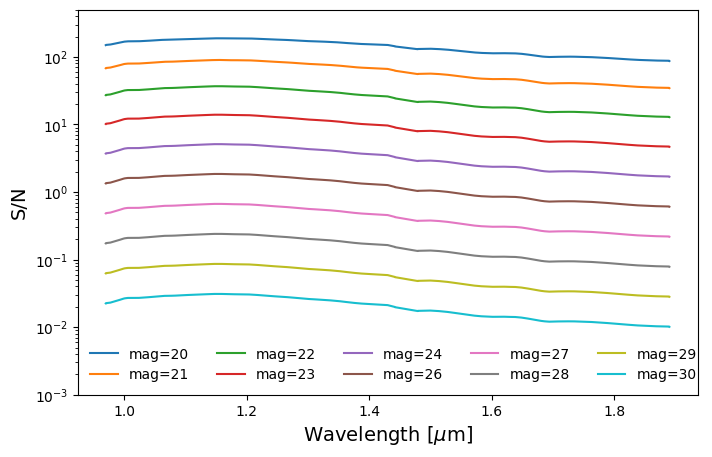

In [2]:
exptime = 40000
magnitudes = np.linspace(20.0, 30.0, 10)

# Define wavelength grid (microns)
waves = np.linspace(0.6, 5.3, 500)

# Dictionary to store all results
# Structure: results[magnitude] = snr_dict
snr_results = {}
    
for mag in magnitudes:
    # 2. Calculate flux in mJy for a flat AB magnitude spectrum
    # Formula: m_ab = -2.5 * log10(f_nu_Jy / 3631)
    # So: f_nu_mJy = 3631 * 10^(-mag / 2.5) * 10^3
    flux_mjy_val = 3631 * 10**(-mag / 2.5) * 1e3
    fluxes = np.ones_like(waves) * flux_mjy_val
        
    # 3. Run the Pandeia engine function
    # Note: We pass exptime as the third argument (exposure_time_sec)
    snr_dict = run_nirspec_ifu(waves, fluxes, exptime)
        
    # Store result
    snr_results[mag] = snr_dict

# plotting
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,5))
f1 = plt.subplot()
f1.set_yscale('log')
plt.xlabel(r'Wavelength [$\mu$m]', fontsize=14)
plt.ylabel('S/N', fontsize=14)
plt.ylim(1e-3,5e+2)

for mag in magnitudes:
    plt.plot(snr_results[mag]['g140h/f100lp']['det2']['wave'], snr_results[mag]['g140h/f100lp']['det2']['sn'], label='mag=%.0lf' % mag)

plt.legend(fontsize=10, frameon=False, ncol=5)

Then we will use the derived S/N curves to estimate the magnitude limits at S/N=5 across the wavelength grids.

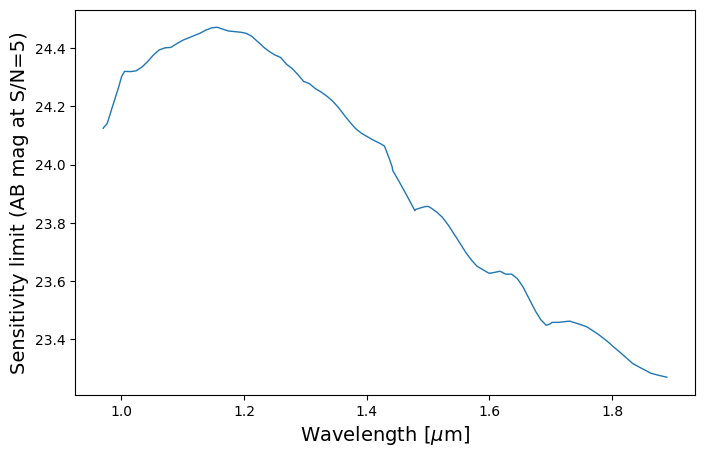

In [3]:
sensitivity_dict = calculate_sensitivity_limits(snr_results, target_snr=5.0)
sensitivity_wave = sensitivity_dict['g140h/f100lp']['common_wave']
sensitivity_mag_lims = sensitivity_dict['g140h/f100lp']['det2']

fig = plt.figure(figsize=(8,5))
f1 = plt.subplot()
#f1.set_yscale('log')
plt.xlabel(r'Wavelength [$\mu$m]', fontsize=14)
plt.ylabel('Sensitivity limit (AB mag at S/N=5)', fontsize=14)

plt.plot(sensitivity_wave, sensitivity_mag_lims, lw=1)

### Configuring the IFU observation pipeline
The ``GalSynMockObservation_ifu`` module processes the data through a specific sequence designed for 3D spectroscopic data:
* Spectral Grid Alignment: The high-resolution synthetic cube is interpolated onto your ``desired_wave_grid``.
* Spatial Resampling: The cube is resampled to the ``final_pixel_scale_arcsec`` while maintaining flux conservation.
* Spectral Smoothing: Each spaxel is convolved along the wavelength axis with a Gaussian kernel to match the target instrumental resolution ($R$).
* Spatial PSF Convolution: The cube is convolved slice-by-slice using the 3D PSF cube to account for wavelength-dependent blurring.
* Noise Injection: Realistic, wavelength-dependent noise is injected independently into each slice.

Additional notes:
- Wavelength-dependent parameters: unlike imaging, parameters like ``limiting_magnitude`` and ``exposure_time`` can be provided as functions of wavelength to model instrument sensitivity variations accurately.
- Spectral smoothing: the module uses your ``spectral_resolution_R`` to derive the kernel width ($\sigma = \lambda / R / 2.355$) for each wavelength channel.

In [6]:
from scipy.interpolate import interp1d
from galsyn import GalSynMockObservation_ifu


fits_file_path = 'galsyn_39_107965_specphoto.fits'
desired_wave_grid = cube_psf_wave_um * 1e+4  # Convert microns to Angstroms
psf_cube_path = 'psf_G140H_F100LP_standard.fits'

# Observation parameters
psf_pixel_scale = 0.1
spectral_resolution_R = 2700
mag_zp = 25.472125665882295
exposure_time = 40000
final_pixel_scale_arcsec = 0.1

# Define a wavelength-dependent limiting magnitude function
limiting_magnitude_wave_func = interp1d(sensitivity_wave * 1e+4, sensitivity_mag_lims, fill_value="extrapolate")
snr_limit = 5.0

# Initialize and run the IFU pipeline
sifu = GalSynMockObservation_ifu(fits_file_path, desired_wave_grid, psf_cube_path, psf_pixel_scale,
                spectral_resolution_R, mag_zp, limiting_magnitude_wave_func, snr_limit,
                final_pixel_scale_arcsec, exposure_time)

sifu.process_datacube(dust_attenuation=True, apply_noise_to_cube=True)

# Save the final realistic IFU data cube
output_fits_path = 'obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits'
sifu.save_results_to_fits(output_fits_path)


Starting IFU Pipeline: Resample -> Smoothing -> PSF -> Noise
Processing IFU data for dust_attenuation=True
  Resampling spatially to 0.1000 arcsec (Bicubic)...
  Smoothing spectra to R=2700...
  Convolving each spatial slice with PSF...
  Simulating and injecting noise...
IFU results saved to obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits


### Check resulting data cube

In [7]:
cube = fits.open('obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits')
cube.info()

Filename: obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  SCI_DUST      1 ImageHDU        20   (104, 104, 4600)   float64   
  2  RMS_DUST      1 ImageHDU        20   (104, 104, 4600)   float64   
  3  WAVELENGTH_GRID    1 BinTableHDU     11   4600R x 1C   [D]   


physical scale of pixel: 0.8686865785764436 kpc


/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_80366/510061876.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()
/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_80366/510061876.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()


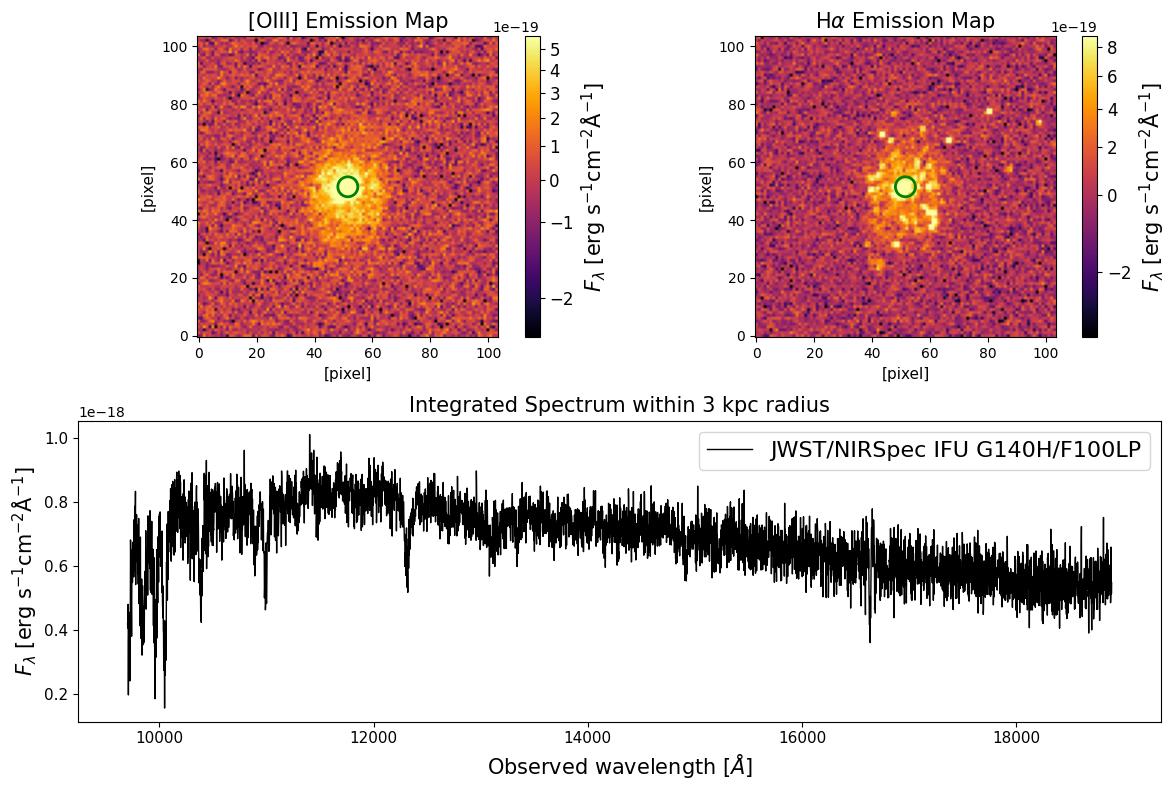

In [8]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches 
import matplotlib.cm as cm 
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

sci_data = cube['SCI_DUST'].data
wavelength = cube['WAVELENGTH_GRID'].data['WAVELENGTH']

# get physical scale of pixel in kpc
z = 1.531239    # redshift 
kpc_per_arcsec = 1.0 / cosmo.arcsec_per_kpc_proper(z).value
pix_kpc = cube[0].header['pixsize'] * kpc_per_arcsec
print (f'physical scale of pixel: {pix_kpc} kpc')
radius_kpc = 3.0
radius_pixels = radius_kpc / pix_kpc

# Select wavelength grids around the OIII and H-alpha lines
oiii_wave_range = [5007*(1.0+z)-150, 5007*(1.0+z)+150]
halpha_wave_range = [6564*(1.0+z)-150, 6564*(1.0+z)+150]
oiii_indices = np.where((wavelength >= oiii_wave_range[0]) & (wavelength <= oiii_wave_range[1]))[0]
halpha_indices = np.where((wavelength >= halpha_wave_range[0]) & (wavelength <= halpha_wave_range[1]))[0]

# Integrate to get the 2D maps
oiii_map = np.sum(sci_data[oiii_indices, :, :], axis=0)
halpha_map = np.sum(sci_data[halpha_indices, :, :], axis=0)

# Get the spatial dimensions
nz, ny, nx = sci_data.shape
center_x, center_y = (nx-1.0)/2.0, (ny-1.0)/2.0

# Create a circular mask
y, x = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
mask = dist_from_center <= radius_pixels

# Create masked data cube
masked_sci_data0 = sci_data * mask

# Integrated spectrum
integrated_spectrum0 = np.sum(masked_sci_data0, axis=(1, 2))

# Create the multipanel plot
plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# OIII map
ax0 = plt.subplot(gs[0, 0])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(oiii_map, 'sqrt', percent=98.5)
im0 = ax0.imshow(oiii_map, norm=norm, origin='lower', cmap=cmap)

ax0.set_title('[OIII] Emission Map', fontsize=15)
ax0.set_xlabel('[pixel]', fontsize=11)
ax0.set_ylabel('[pixel]', fontsize=11)
#plt.colorbar(im0, ax=ax0, label='Integrated Flux')

cbar = plt.colorbar(im0, ax=ax0)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to OIII map
circle0 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax0.add_patch(circle0)
# End of new code

# H-alpha map
ax1 = plt.subplot(gs[0, 1])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(halpha_map, 'sqrt', percent=98.5)
im1 = ax1.imshow(halpha_map, norm=norm, origin='lower', cmap=cmap)

ax1.set_title(r'H$\alpha$ Emission Map', fontsize=15)
ax1.set_xlabel('[pixel]', fontsize=11)
ax1.set_ylabel('[pixel]', fontsize=11)

cbar = plt.colorbar(im1, ax=ax1)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to H-alpha map
circle1 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax1.add_patch(circle1)
# End of new code

# Integrated spectrum
ax2 = plt.subplot(gs[1, :])
ax2.plot(wavelength, integrated_spectrum0, lw=1, color='black', label='JWST/NIRSpec IFU G140H/F100LP')
ax2.set_title('Integrated Spectrum within 3 kpc radius', fontsize=15)
ax2.set_xlabel(r'Observed wavelength [$\AA$]', fontsize=15)
ax2.set_ylabel(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
plt.setp(ax2.get_yticklabels(), fontsize=11)
plt.setp(ax2.get_xticklabels(), fontsize=11)
plt.legend(fontsize=16)

plt.tight_layout()